# Robustness-Aware Smishing Detection

> **Note:** Training was completed separately. This notebook loads saved checkpoints
> from `saved_models/` and runs the full corrected evaluation pipeline.

## 1. Imports & Device Setup

In [1]:
import os, re, gc, time, unicodedata, warnings
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm.auto import tqdm
import Levenshtein
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM: 4.0 GB


## 2. Data Preprocessing

Rebuild `test_df` with the **same random state and splits** used during training,
so evaluation operates on the identical held-out partition.

In [2]:
df = pd.read_csv('Combined-Labeled-Dataset.csv')
df = df[['message', 'smishing label']].rename(columns={'smishing label': 'label'})

initial_len = len(df)
df.drop_duplicates(subset=['message'], inplace=True)
print(f'Removed {initial_len - len(df)} duplicates. Remaining: {len(df):,} messages.')

df['message'] = df['message'].apply(lambda x: unicodedata.normalize('NFKC', str(x)))

# Identical split to training — random_state=42 guarantees same partitions
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df,   test_df = train_test_split(test_df, test_size=0.5, stratify=test_df['label'], random_state=42)

print(f'Split — Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print(f"Test label distribution:\n{test_df['label'].value_counts(normalize=True).round(4)}")

Removed 10280 duplicates. Remaining: 74,583 messages.
Split — Train: 59,666 | Val: 7,458 | Test: 7,459
Test label distribution:
label
0    0.6927
1    0.3073
Name: proportion, dtype: float64


## 3. Adversarial Attack Module

In [ ]:
class AdversarialAttacker:
    def __init__(self):
        self.homoglyph_map = {
            'a': chr(0x0430), 'c': chr(0x0441), 'e': chr(0x0435),
            'h': chr(0x04BB), 'i': chr(0x0456), 'j': chr(0x0458),
            'k': chr(0x03BA), 'l': chr(0x04CF), 'o': chr(0x043E),
            'p': chr(0x0440), 'r': chr(0x0433), 's': chr(0x0455),
            'u': chr(0x03C5), 'v': chr(0x03BD), 'x': chr(0x0445),
            'y': chr(0x0443),
        }
        # All 4 invisible chars
        self.invisible_chars = ['\u200B', '\u200C', '\u200D', '\uFEFF']

    def apply_homoglyph(self, text: str, prob: float = 0.2) -> str:
        return ''.join(
            self.homoglyph_map.get(c.lower(), c) if np.random.rand() < prob else c
            for c in text
        )

    def apply_invisible(self, text: str, prob: float = 0.1) -> str:
        res = []
        for c in text:
            res.append(c)
            if np.random.rand() < prob:
                res.append(np.random.choice(self.invisible_chars))
        return ''.join(res)

    # prob parameter explicit
    def apply_layered(self, text: str, prob: float = 0.2) -> str:
        text = self.apply_homoglyph(text, prob)
        text = self.apply_invisible(text, prob)
        return text

attacker = AdversarialAttacker()
print('AdversarialAttacker initialized.')
print(f'Homoglyph map: {len(attacker.homoglyph_map)} characters')
print(f'Invisible chars: {len(attacker.invisible_chars)} characters')

AdversarialAttacker initialized.
Homoglyph map: 16 characters
Invisible chars: 4 characters


## 4. Defense Module

1. Strip invisible chars (prevents interference with NFKC boundaries)
2. NFKC normalization (handles compatibility equivalences broadly)
3. Reverse homoglyph lookup (resolves residual chars outside NFKC scope)


In [4]:
class CharacterReconstruction:
    def __init__(self, homoglyph_map: dict):
        self.reverse_map     = {v: k for k, v in homoglyph_map.items()}
        self.invisible_chars = ['\u200B', '\u200C', '\u200D', '\uFEFF']

    def reconstruct(self, text: str) -> str:
        # Step 1: Strip invisible control characters
        for char in self.invisible_chars:
            text = text.replace(char, '')
        # Step 2: NFKC normalization
        text = unicodedata.normalize('NFKC', text)
        # Step 3: Reverse homoglyph substitution
        return ''.join(self.reverse_map.get(c, c) for c in text)

defense = CharacterReconstruction(attacker.homoglyph_map)

# Sanity check
np.random.seed(42)
sample    = 'Please click this link to verify your account: http://bit.ly/secure'
attacked  = attacker.apply_layered(sample)
recovered = defense.reconstruct(attacked)
rss       = 1 - Levenshtein.distance(recovered, sample) / max(len(recovered), len(sample))
print(f'Original:      {sample}')
print(f'Attacked:      {attacked}')
print(f'Reconstructed: {recovered}')
print(f'RSS: {rss:.4f}  |  Match: {"PERFECT" if recovered == sample else "PARTIAL"}')

Original:      Please click this link to verify your account: http://bit.ly/secure
Attacked:      Pl‍eaѕе‍ cli‍сk tһ‍іs linκ‌ to ν‍er​іfу yo‍ur a‍cсoυn﻿t:‌ ht​tp​:/​/b﻿it.ӏy/﻿securе
Reconstructed: Please click this link to verify your account: http://bit.ly/secure
RSS: 1.0000  |  Match: PERFECT


## 5. Evaluation Function


In [ ]:
N_LAT_RUNS = 10  # averaged latency runs per sample

def evaluate_robustness(
    model, tokenizer,
    eval_df:      pd.DataFrame,
    attack_type:  str   = None,
    use_defense:  bool  = False,
    prob:         float = 0.2,
    n_lat_runs:   int   = N_LAT_RUNS
) -> dict:
    """
    Evaluate one (model, attack_type, defense) configuration.

    Parameters
    ----------
    eval_df     : Full evaluation partition - no internal slicing.
    attack_type : None | 'homoglyph' | 'invisible' | 'layered'
    use_defense : Whether to apply CharacterReconstruction before tokenization.
    prob        : Perturbation probability forwarded to the attacker.
    n_lat_runs  : Number of timed inference passes per sample (post warm-up).
    """
    model.eval()
    preds, actuals, rss_scores, latencies = [], [], [], []

    tag = f"{attack_type or 'clean'} | def={use_defense} | rho={prob}"

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc=f'  [{tag}]', leave=False):
        original_text = row['message']

        # Apply attack
        if   attack_type == 'homoglyph': text = attacker.apply_homoglyph(original_text, prob)
        elif attack_type == 'invisible': text = attacker.apply_invisible(original_text, prob)
        elif attack_type == 'layered':   text = attacker.apply_layered(original_text, prob)
        else:                            text = original_text

        # Optional defense
        if use_defense:
            text = defense.reconstruct(text)
            rss  = 1 - Levenshtein.distance(text, original_text) \
                       / max(len(text), len(original_text), 1)
            rss_scores.append(rss)

        inputs = tokenizer(
            text, return_tensors='pt',
            truncation=True, padding=True, max_length=128
        ).to(device)

        # Warm-up pass (excluded from timing)
        with torch.no_grad():
            _ = model(**inputs)

        # Timed passes
        run_times = []
        for _ in range(n_lat_runs):
            t0 = time.perf_counter()
            with torch.no_grad():
                out = model(**inputs)
            run_times.append((time.perf_counter() - t0) * 1000)

        latencies.append(float(np.mean(run_times)))
        preds.append(torch.argmax(out.logits).item())
        actuals.append(row['label'])

    return {
        'precision': precision_score(actuals, preds, zero_division=0),
        'recall':    recall_score(actuals,    preds, zero_division=0),  
        'f1':        f1_score(actuals,         preds, zero_division=0),
        'latency':   float(np.mean(latencies)),
        'rss':       float(np.mean(rss_scores)) if rss_scores else 1.0,
    }

print('evaluate_robustness() ready.')

evaluate_robustness() ready.


## 6. Main Evaluation Loop

Each model is loaded, evaluated across all conditions, then **immediately unloaded**
to stay within VRAM budget.

In [ ]:
PERTURBATION_RATES = [0.1, 0.2, 0.3, 0.5]  # [FIX-5]

models_cfg = [
    ('RoBERTa',     'saved_models/roberta'),
    ('XLM-RoBERTa', 'saved_models/xlm_roberta'),
    ('DeBERTa',     'saved_models/deberta'),
    ('DistilBERT',  'saved_models/distilbert'),
]

# Full test set
eval_set = test_df

summary_rows   = []
rho_sweep_rows = []

for name, path in models_cfg:
    print(f'\n{"="*60}')
    print(f'Evaluating: {name}  |  test samples: {len(eval_set):,}')
    print(f'{"="*60}')

    m = AutoModelForSequenceClassification.from_pretrained(path).to(device)
    t = AutoTokenizer.from_pretrained(path)

    # Tier 0: Clean baseline
    print('  Running Tier 0 — Clean...')
    clean_res = evaluate_robustness(m, t, eval_set)

    # Tier 1: Single-vector attacks at prob=0.2
    print('  Running Tier 1a — Homoglyph only...')
    homo_res  = evaluate_robustness(m, t, eval_set, attack_type='homoglyph', prob=0.2)
    print('  Running Tier 1b — Invisible only...')
    invis_res = evaluate_robustness(m, t, eval_set, attack_type='invisible', prob=0.2)

    # Tier 2: Layered at default rho=0.2 (goes into summary table)
    print('  Running Tier 2 — Layered (rho=0.2)...')
    layered_res  = evaluate_robustness(m, t, eval_set, attack_type='layered', prob=0.2)
    print('  Running Tier 2 + Defense...')
    defended_res = evaluate_robustness(m, t, eval_set, attack_type='layered',
                                       use_defense=True, prob=0.2)

    rr = layered_res['f1'] / clean_res['f1'] if clean_res['f1'] > 0 else 0.0

    summary_rows.append({
        'Model':           name,
        'Clean Prec':      round(clean_res['precision'],    3),
        'Clean Recall':    round(clean_res['recall'],       3),
        'Clean F1':        round(clean_res['f1'],           3),
        'T1 Homo F1':      round(homo_res['f1'],            3),
        'T1 Invis F1':     round(invis_res['f1'],           3),
        'T2 Layered F1':   round(layered_res['f1'],         3),
        'RR':              round(rr,                         3),
        'Def Prec':        round(defended_res['precision'], 3),
        'Def Recall':      round(defended_res['recall'],    3),
        'Def F1':          round(defended_res['f1'],        3),
        'RSS':             round(defended_res['rss'],       3),
        'Latency (ms)':    round(clean_res['latency'],      2),
    })

    # Perturbation rate grid
    print(f'  Running Tier 2 rho sweep: {PERTURBATION_RATES}...')
    for rho in PERTURBATION_RATES:
        lr = evaluate_robustness(m, t, eval_set, attack_type='layered', prob=rho)
        dr = evaluate_robustness(m, t, eval_set, attack_type='layered',
                                 use_defense=True, prob=rho)
        rho_sweep_rows.append({
            'Model':       name,
            'rho':         rho,
            'Attacked F1': round(lr['f1'],                                         3),
            'RR':          round(lr['f1'] / clean_res['f1'] if clean_res['f1'] > 0 else 0, 3),
            'Defended F1': round(dr['f1'],                                         3),
            'RSS':         round(dr['rss'],                                        3),
        })

    del m, t
    gc.collect()
    torch.cuda.empty_cache()

final_df = pd.DataFrame(summary_rows)
rho_df   = pd.DataFrame(rho_sweep_rows)

print('\n\n=== MAIN RESULTS TABLE ===')
print(final_df.to_string(index=False))
print('\n\n=== PERTURBATION RATE SWEEP (Tier 2) ===')
print(rho_df.to_string(index=False))


Evaluating: RoBERTa  |  test samples: 7,459


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Running Tier 0 — Clean...


  [clean | def=False | rho=0.2]:   0%|          | 0/7459 [00:00<?, ?it/s]

  Running Tier 1a — Homoglyph only...


...

  [layered | def=False | rho=0.3]:   0%|          | 0/7459 [00:00<?, ?it/s]

  [layered | def=True | rho=0.3]:   0%|          | 0/7459 [00:00<?, ?it/s]

  [layered | def=False | rho=0.5]:   0%|          | 0/7459 [00:00<?, ?it/s]

  [layered | def=True | rho=0.5]:   0%|          | 0/7459 [00:00<?, ?it/s]



=== MAIN RESULTS TABLE ===
      Model  Clean Prec  Clean Recall  Clean F1  T1 Homo F1  T1 Invis F1  T2 Layered F1    RR  Def Prec  Def Recall  Def F1   RSS  Latency (ms)
    RoBERTa       0.982         0.978     0.980       0.789        0.718          0.393 0.401     0.983       0.969   0.976 0.991         21.77
XLM-RoBERTa       0.977         0.986     0.981       0.785        0.757          0.493 0.502     0.978       0.975   0.976 0.991         15.49
    DeBERTa       0.989         0.980     0.985       0.760        0.750          0.439 0.446     0.988       0.967   0.978 0.992         46.26
 DistilBERT       0.987         0.982     0.984       0.763        0.984          0.775 0.787     0.987       0.982   0.984 0.992          7.81


=== PERTURBATION RATE SWEEP (Tier 2) ===
      Model  rho  Attacked F1    RR  Defended F1   RSS
    RoBERTa  0.1        0.767 0.783        0.978 0.996
    RoBERTa  0.2        0.406 0.414        0.978 0.992
    RoBERTa  0.3        0.117 0.119        

## 7. Save Results to CSV

In [7]:
os.makedirs('output/results', exist_ok=True)
final_df.to_csv('output/results/main_results.csv',     index=False)
rho_df.to_csv('output/results/rho_sweep_results.csv',  index=False)
print('Saved: output/results/main_results.csv')
print('Saved: output/results/rho_sweep_results.csv')

Saved: output/results/main_results.csv
Saved: output/results/rho_sweep_results.csv


## 8. Visualizations

Four plots:
1. F1-Score across all tiers (Clean / T1-Homo / T1-Invis / T2 / Defended)
2. Robustness Rate (RR) bar chart
3. F1 degradation curve vs. ρ — supports perturbation rate contribution claim
4. Latency vs. Clean F1 scatter (bubble = RR)

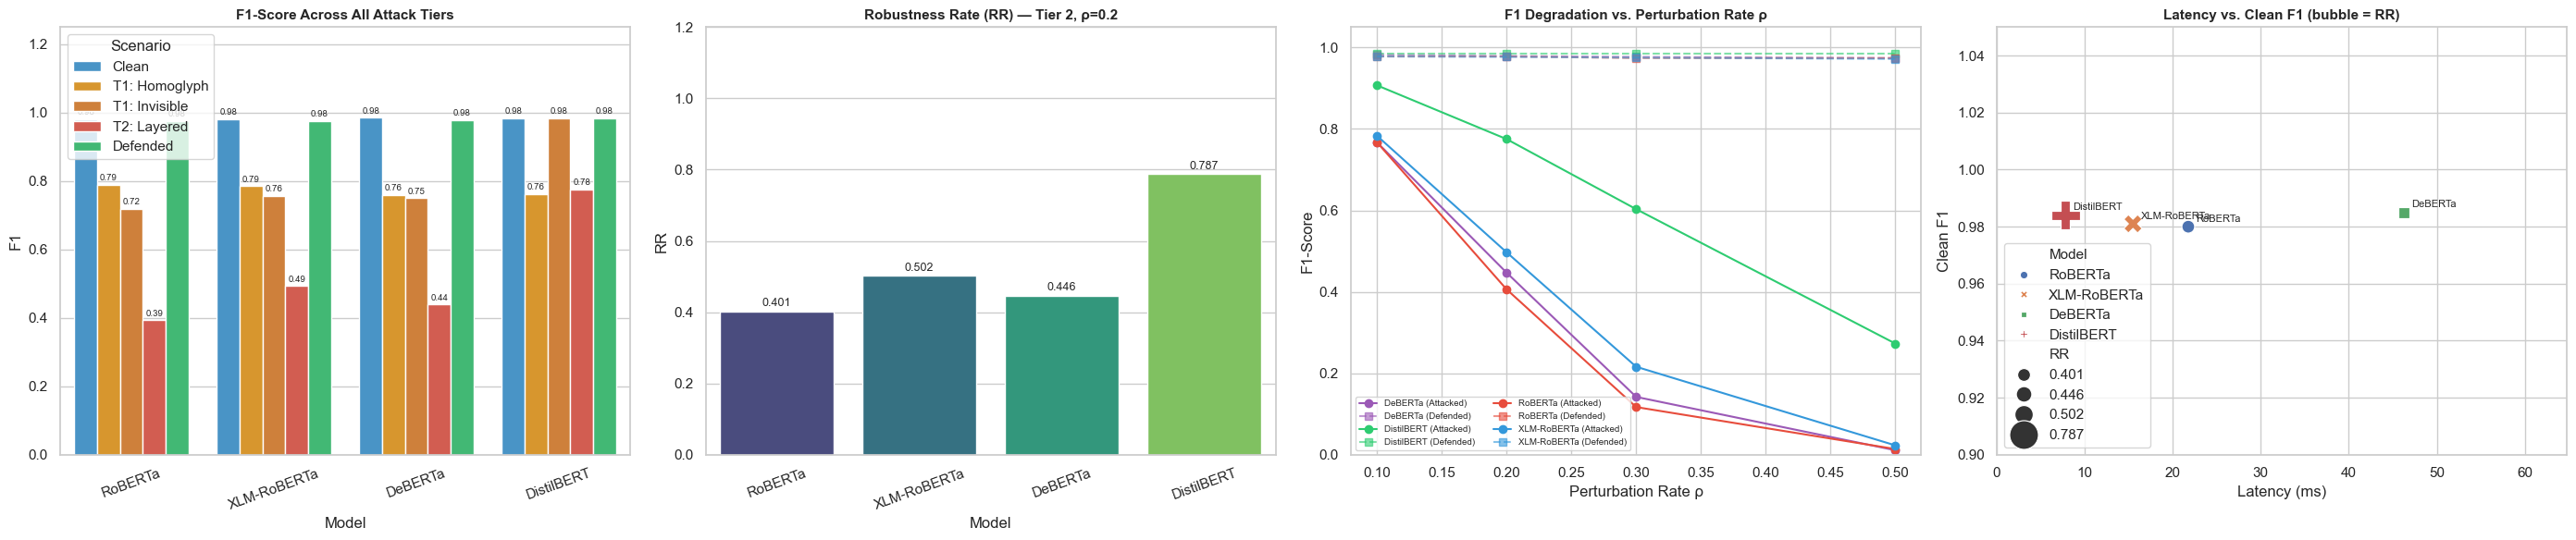

Saved: output/results/full_evaluation_plots.png


In [8]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 4, figsize=(28, 6))

# --- Plot 1: F1 across all tiers ---
plot_data = []
for _, row in final_df.iterrows():
    for scenario, col in [
        ('Clean',          'Clean F1'),
        ('T1: Homoglyph',  'T1 Homo F1'),
        ('T1: Invisible',  'T1 Invis F1'),
        ('T2: Layered',    'T2 Layered F1'),
        ('Defended',       'Def F1'),
    ]:
        plot_data.append({'Model': row['Model'], 'F1': row[col], 'Scenario': scenario})

plot_df = pd.DataFrame(plot_data)
ax1 = sns.barplot(ax=axes[0], x='Model', y='F1', hue='Scenario', data=plot_df,
                  palette=['#3498db','#f39c12','#e67e22','#e74c3c','#2ecc71'])
axes[0].set_title('F1-Score Across All Attack Tiers', fontsize=11, fontweight='bold')
axes[0].set_ylim(0.0, 1.25)
axes[0].tick_params(axis='x', rotation=20)
for p in ax1.patches:
    if p.get_height() > 0.01:
        ax1.annotate(f"{p.get_height():.2f}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=7, xytext=(0, 2),
                     textcoords='offset points')

# --- Plot 2: Robustness Rate ---
ax2 = sns.barplot(ax=axes[1], x='Model', y='RR', data=final_df, palette='viridis')
axes[1].set_title('Robustness Rate (RR) — Tier 2, ρ=0.2', fontsize=11, fontweight='bold')
axes[1].set_ylim(0.0, 1.2)
axes[1].tick_params(axis='x', rotation=20)
for p in ax2.patches:
    if p.get_height() > 0.01:
        ax2.annotate(f"{p.get_height():.3f}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 2),
                     textcoords='offset points')

# --- Plot 3: ρ sweep degradation curves ---
colors = {'RoBERTa': '#e74c3c', 'XLM-RoBERTa': '#3498db',
          'DeBERTa': '#9b59b6', 'DistilBERT': '#2ecc71'}
for model_name, grp in rho_df.groupby('Model'):
    c = colors.get(model_name, 'gray')
    axes[2].plot(grp['rho'], grp['Attacked F1'],  marker='o', color=c,
                 label=f'{model_name} (Attacked)')
    axes[2].plot(grp['rho'], grp['Defended F1'], marker='s', color=c,
                 linestyle='--', alpha=0.6, label=f'{model_name} (Defended)')
axes[2].set_title('F1 Degradation vs. Perturbation Rate ρ', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Perturbation Rate ρ')
axes[2].set_ylabel('F1-Score')
axes[2].set_ylim(0.0, 1.05)
axes[2].legend(fontsize=7, ncol=2)

# --- Plot 4: Latency vs Clean F1 ---
ax4 = sns.scatterplot(ax=axes[3], x='Latency (ms)', y='Clean F1',
                      hue='Model', style='Model', size='RR',
                      sizes=(100, 500), data=final_df, palette='deep')
for _, row in final_df.iterrows():
    axes[3].annotate(row['Model'],
                     (row['Latency (ms)'], row['Clean F1']),
                     textcoords='offset points', xytext=(6, 4), fontsize=8)
axes[3].set_title('Latency vs. Clean F1 (bubble = RR)', fontsize=11, fontweight='bold')
axes[3].set_xlim(0, final_df['Latency (ms)'].max() * 1.4)
axes[3].set_ylim(0.9, 1.05)

plt.tight_layout()
plt.savefig('output/results/full_evaluation_plots.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: output/results/full_evaluation_plots.png')